# 03 ? Multivariate Analysis (Hypothesis Visualization)

This notebook visualizes **multivariate** relationships aligned to the hypotheses in `problem_definition.txt`.

Guardrails:
- **No hypothesis tests** (no p-values, no model fitting/inference).
- The dataset has **no timestamps**, so retention is approximated with within-dataset engagement proxies (`repeat_customer_flag`, `n_orders`).
- If `*.new.csv` versions exist (created when original CSVs were locked), this notebook auto-loads those.

In [2]:
%pip install pathlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 11

In [5]:
def resolve_processed_path(stem: str) -> Path:
    base = Path("data/processed")
    new_path = base / f"{stem}.new.csv"
    old_path = base / f"{stem}.csv"
    return new_path if new_path.exists() else old_path

orders_path = resolve_processed_path("orders_features")
customers_path = resolve_processed_path("customer_features")
restaurants_path = resolve_processed_path("restaurant_features")
cuisines_path = resolve_processed_path("cuisine_features")

orders = pd.read_csv(r"C:\Users\dnune\OneDrive\Desktop\WEEK_2.0_PROJECT\data\processed\orders_features.new.csv")
customers = pd.read_csv(r"C:\Users\dnune\OneDrive\Desktop\WEEK_2.0_PROJECT\data\processed\customer_features.new.csv")
restaurants = pd.read_csv(r"C:\Users\dnune\OneDrive\Desktop\WEEK_2.0_PROJECT\data\processed\restaurant_features.new.csv")
cuisines = pd.read_csv(r"C:\Users\dnune\OneDrive\Desktop\WEEK_2.0_PROJECT\data\processed\cuisine_features.new.csv")

orders_path, customers_path, restaurants_path, cuisines_path

(WindowsPath('data/processed/orders_features.csv'),
 WindowsPath('data/processed/customer_features.csv'),
 WindowsPath('data/processed/restaurant_features.csv'),
 WindowsPath('data/processed/cuisine_features.csv'))

In [6]:
def quick_check(df: pd.DataFrame, name: str):
    print(f"{name}: shape={df.shape}")
    miss = df.isna().mean().mul(100).sort_values(ascending=False)
    miss = miss[miss > 0]
    if miss.empty:
        print("  missing: none")
    else:
        print("  missing top (%):")
        display(miss.head(10).to_frame("missing_%").round(3))

quick_check(orders, "orders")
quick_check(customers, "customers")
quick_check(restaurants, "restaurants")
quick_check(cuisines, "cuisines")

orders: shape=(1898, 16)
  missing top (%):


,missing_%
top_rating_flag,38.778
high_rating_flag,38.778
rating_num,38.778


customers: shape=(1200, 26)
  missing top (%):


,missing_%
std_prep_time,65.333
std_cost,65.333
std_delivery_time,65.333
std_total_fulfillment_time,65.333
delivery_time_cv,65.333
total_time_cv,65.333
avg_rating,28.417
pct_high_rating,28.417
pct_top_rating,28.417


restaurants: shape=(178, 16)
  missing top (%):


,missing_%
delivery_time_cv,28.09
std_delivery_time,28.09
pct_high_rating,12.36
avg_rating,12.36
pct_top_rating,12.36


cuisines: shape=(14, 10)
  missing: none


## Prep: helper bins (for faceting)

Binning makes multivariate visuals easier to read.

In [7]:
cust = customers.copy()

# Safe copies for plotting
cust["repeat_customer_flag"] = cust["repeat_customer_flag"].astype(bool)

# Quantile bins
cust["avg_delivery_time_q"] = pd.qcut(cust["avg_delivery_time"], q=4, duplicates="drop")
cust["avg_total_time_q"] = pd.qcut(cust["avg_total_fulfillment_time"], q=4, duplicates="drop")

# Weekend share bins
cust["weekend_share_bin"] = pd.cut(
    cust["weekend_share"],
    bins=[-0.001, 0.001, 0.499, 0.999, 1.001],
    labels=["0%", "(0,50%)", "[50,100%)", "100%"],
)

# Variety bins
cust["cuisine_variety_bin"] = pd.cut(
    cust["cuisine_variety"],
    bins=[0, 1, 2, 4, 100],
    labels=["1", "2", "3-4", "5+"],
    include_lowest=True,
)

cust[["avg_delivery_time_q","avg_total_time_q","weekend_share_bin","cuisine_variety_bin"]].head()

,avg_delivery_time_q,avg_total_time_q,weekend_share_bin,cuisine_variety_bin
0,"(24.5, 28.0]","(34.999, 48.0]",100%,1
1,"(21.0, 24.5]","(48.0, 52.0]",100%,1
2,"(28.0, 33.0]","(48.0, 52.0]",100%,1
3,"(28.0, 33.0]","(56.0, 68.0]",0%,1
4,"(28.0, 33.0]","(56.0, 68.0]",0%,1


## H1: Delivery speed/consistency ? repeat/retention (proxy)

Multivariate views: delivery speed vs engagement, segmented by spend and weekend behavior.

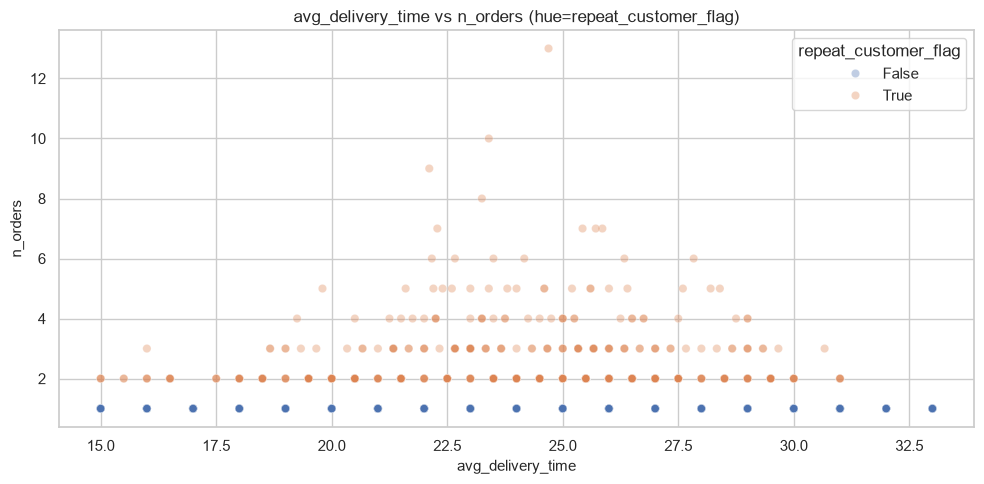

In [8]:
# Hexbin-style density: avg_delivery_time vs n_orders, colored by repeat flag
plt.figure(figsize=(10, 5))

sns.scatterplot(
    data=cust,
    x="avg_delivery_time",
    y="n_orders",
    hue="repeat_customer_flag",
    alpha=0.35,
)
plt.title("avg_delivery_time vs n_orders (hue=repeat_customer_flag)")
plt.tight_layout()
plt.show()

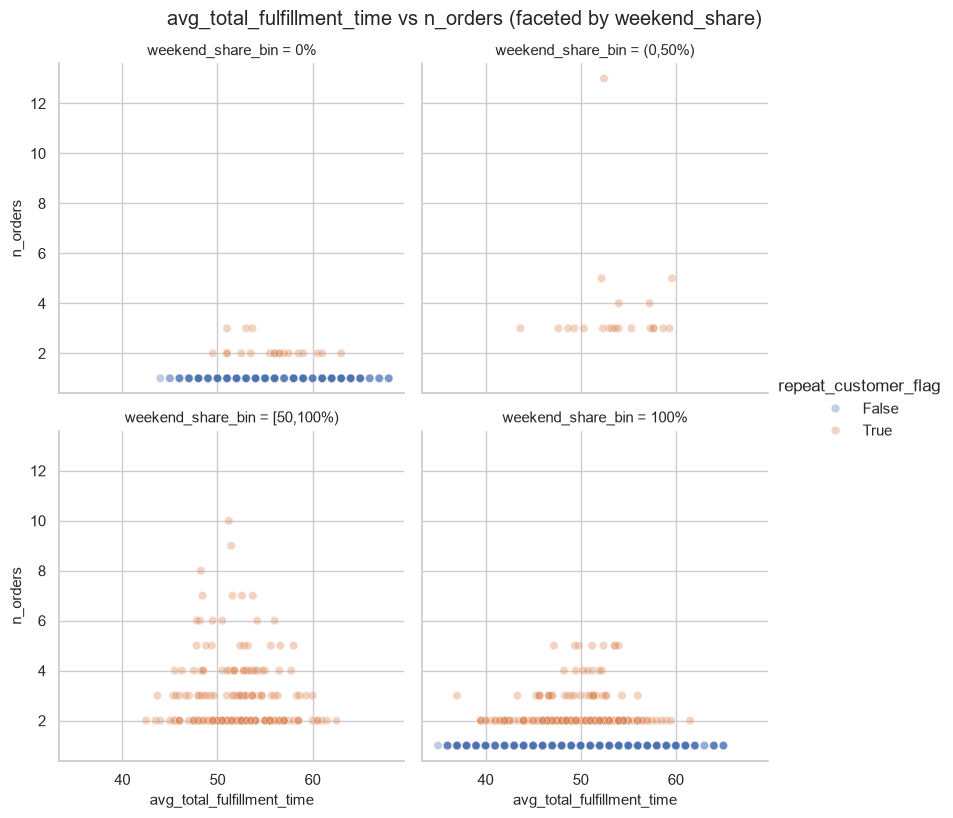

In [9]:
# Facet: avg_total_fulfillment_time vs n_orders across weekend_share bins
p = sns.relplot(
    data=cust,
    x="avg_total_fulfillment_time",
    y="n_orders",
    col="weekend_share_bin",
    hue="repeat_customer_flag",
    kind="scatter",
    alpha=0.35,
    col_wrap=2,
    height=4,
)
p.fig.suptitle("avg_total_fulfillment_time vs n_orders (faceted by weekend_share)", y=1.02)
plt.show()

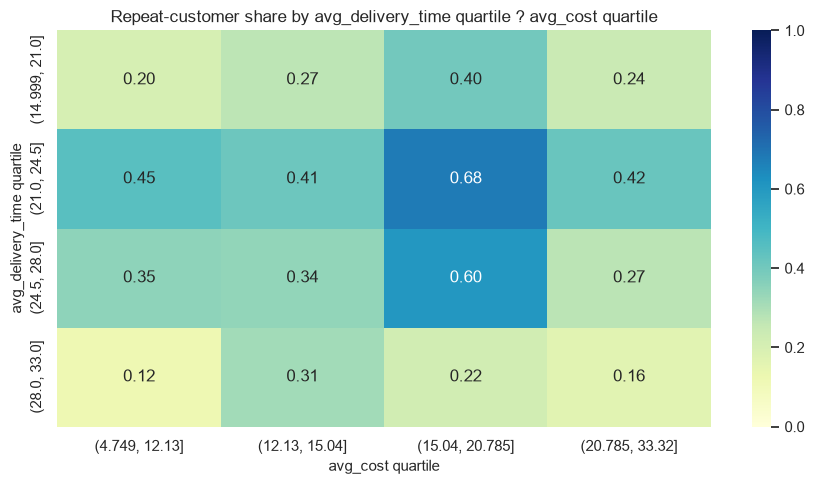

In [10]:
# 2D heatmap: repeat rate by (delivery time quartile x cost quartile)
# This is descriptive aggregation only.
heat = cust.copy()
heat["avg_cost_q"] = pd.qcut(heat["avg_cost"], q=4, duplicates="drop")

pivot = (
    heat
    .groupby(["avg_delivery_time_q", "avg_cost_q"], dropna=False)["repeat_customer_flag"]
    .mean()
    .reset_index(name="repeat_rate")
    .pivot(index="avg_delivery_time_q", columns="avg_cost_q", values="repeat_rate")
)

plt.figure(figsize=(9, 5))
sns.heatmap(pivot, annot=True, fmt=".2f", cmap="YlGnBu", vmin=0, vmax=1)
plt.title("Repeat-customer share by avg_delivery_time quartile ? avg_cost quartile")
plt.xlabel("avg_cost quartile")
plt.ylabel("avg_delivery_time quartile")
plt.tight_layout()
plt.show()

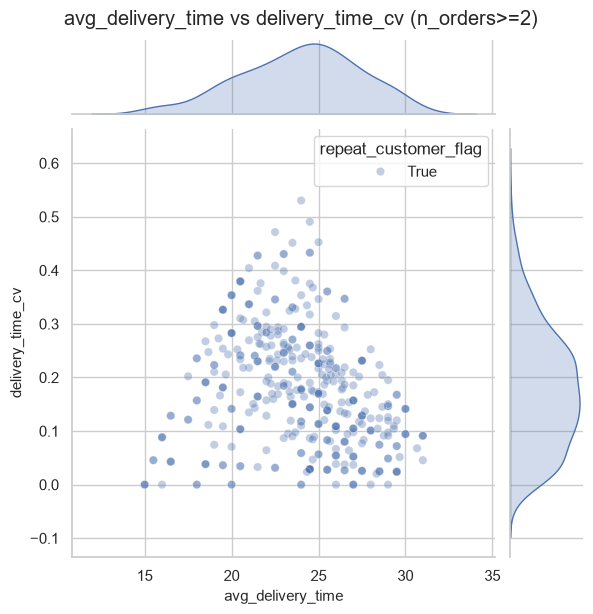

In [11]:
# Consistency vs speed: delivery_time_cv vs avg_delivery_time (n_orders>=2)
if "has_2plus_orders" in cust.columns:
    cons = cust.loc[cust["has_2plus_orders"] == True].copy()
else:
    cons = cust.loc[cust["n_orders"] >= 2].copy()

sns.jointplot(
    data=cons,
    x="avg_delivery_time",
    y="delivery_time_cv",
    hue="repeat_customer_flag",
    height=6,
    alpha=0.35,
)
plt.suptitle("avg_delivery_time vs delivery_time_cv (n_orders>=2)", y=1.02)
plt.show()

## H2: Ratings ? repeat ordering

Multivariate views: rating proxies vs engagement, segmented by delivery speed.

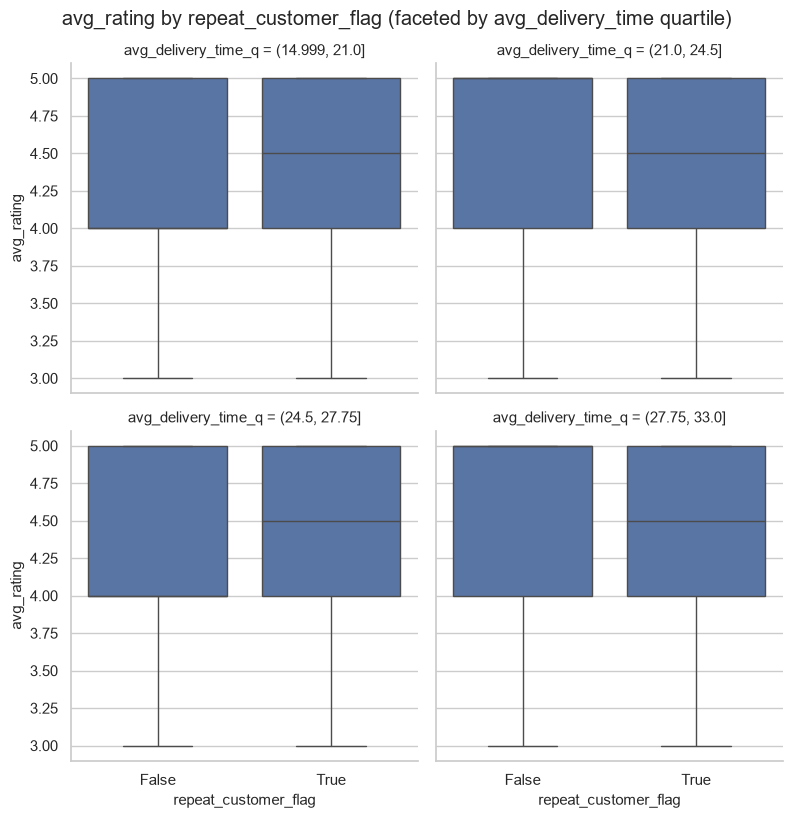

In [12]:
# Customers with at least one rated order
if "has_rated_orders" in cust.columns:
    cust_rated = cust.loc[cust["has_rated_orders"] == True].copy()
else:
    cust_rated = cust.loc[cust["rated_share"] > 0].copy()

cust_rated["avg_delivery_time_q"] = pd.qcut(cust_rated["avg_delivery_time"], q=4, duplicates="drop")

p = sns.catplot(
    data=cust_rated,
    x="repeat_customer_flag",
    y="avg_rating",
    col="avg_delivery_time_q",
    kind="box",
    col_wrap=2,
    height=4,
)
p.fig.suptitle("avg_rating by repeat_customer_flag (faceted by avg_delivery_time quartile)", y=1.02)
plt.show()

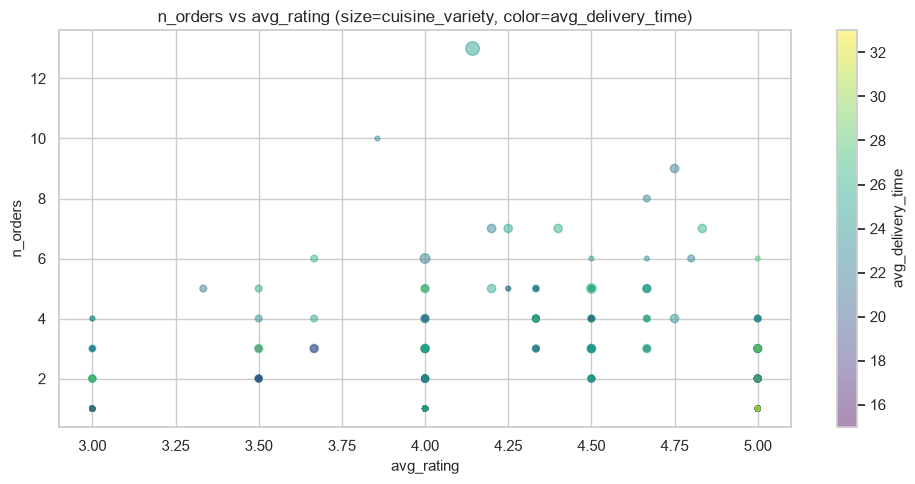

In [13]:
# Bubble plot: avg_rating vs n_orders, size=cuisine_variety, hue=avg_delivery_time
cust_rated = cust_rated.copy()

plt.figure(figsize=(10, 5))
sc = plt.scatter(
    cust_rated["avg_rating"],
    cust_rated["n_orders"],
    s=(cust_rated["cuisine_variety"].clip(lower=1) * 12),
    c=cust_rated["avg_delivery_time"],
    cmap="viridis",
    alpha=0.45,
)
plt.colorbar(sc, label="avg_delivery_time")
plt.title("n_orders vs avg_rating (size=cuisine_variety, color=avg_delivery_time)")
plt.xlabel("avg_rating")
plt.ylabel("n_orders")
plt.tight_layout()
plt.show()

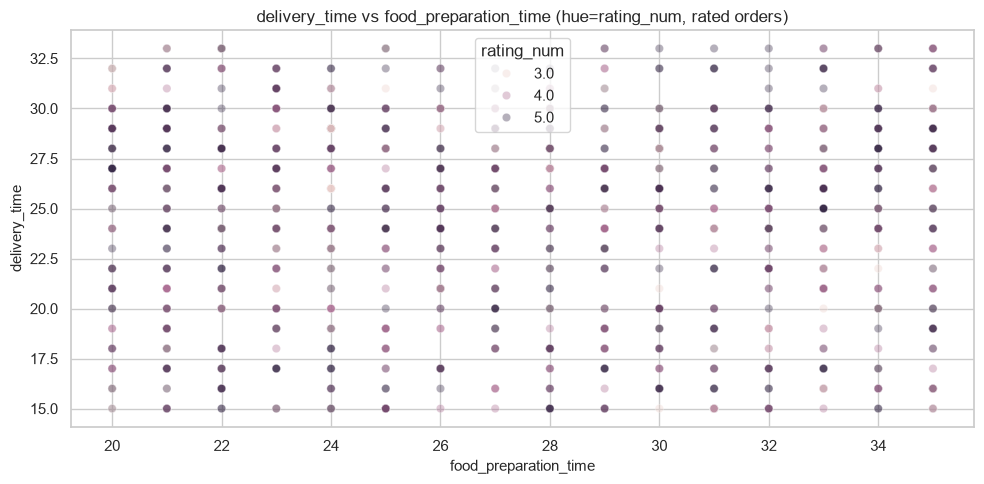

In [14]:
# Order-level: ratings vs (prep_time, delivery_time) for rated orders
rated_orders = orders.loc[orders["rated_flag"] == True].copy()

plt.figure(figsize=(10, 5))
sns.scatterplot(
    data=rated_orders,
    x="food_preparation_time",
    y="delivery_time",
    hue="rating_num",
    alpha=0.35,
)
plt.title("delivery_time vs food_preparation_time (hue=rating_num, rated orders)")
plt.tight_layout()
plt.show()

## H3: Variety ? repeat/retention (proxy)

Multivariate views: variety vs engagement, segmented by delivery speed and spend.

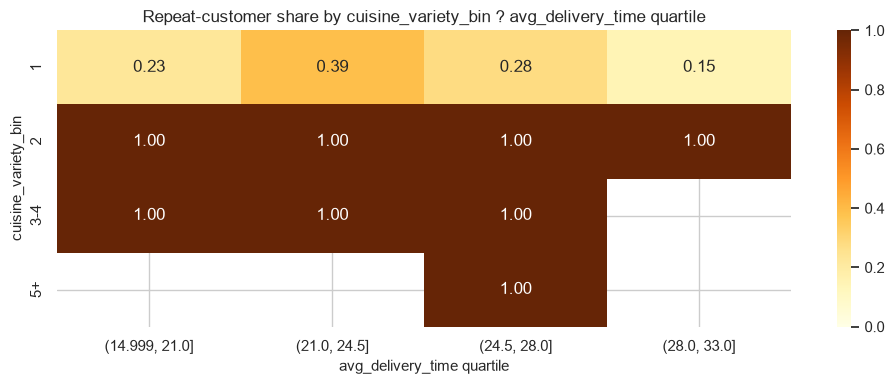

In [15]:
# 2D heatmap: repeat rate by cuisine_variety_bin ? avg_delivery_time quartile
pivot = (
    cust
    .groupby(["cuisine_variety_bin", "avg_delivery_time_q"], dropna=False)["repeat_customer_flag"]
    .mean()
    .reset_index(name="repeat_rate")
    .pivot(index="cuisine_variety_bin", columns="avg_delivery_time_q", values="repeat_rate")
)

plt.figure(figsize=(10, 4))
sns.heatmap(pivot, annot=True, fmt=".2f", cmap="YlOrBr", vmin=0, vmax=1)
plt.title("Repeat-customer share by cuisine_variety_bin ? avg_delivery_time quartile")
plt.xlabel("avg_delivery_time quartile")
plt.ylabel("cuisine_variety_bin")
plt.tight_layout()
plt.show()

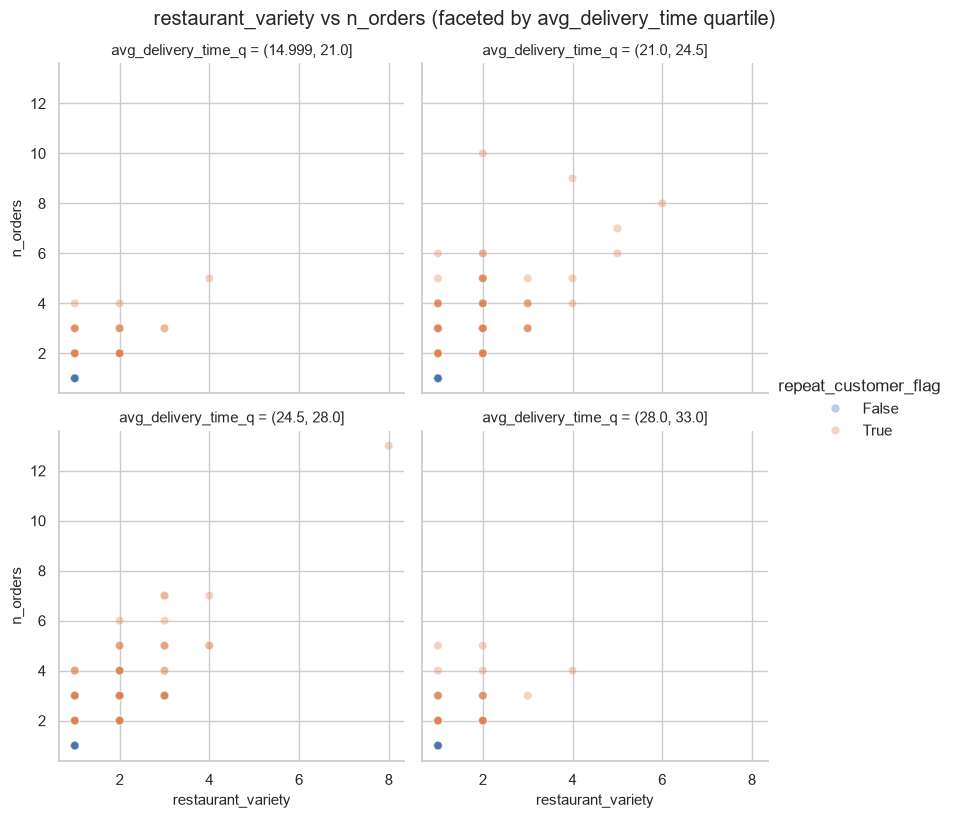

In [16]:
# Facet scatter: restaurant_variety vs n_orders by avg_delivery_time quartile
p = sns.relplot(
    data=cust,
    x="restaurant_variety",
    y="n_orders",
    col="avg_delivery_time_q",
    hue="repeat_customer_flag",
    kind="scatter",
    alpha=0.35,
    col_wrap=2,
    height=4,
)
p.fig.suptitle("restaurant_variety vs n_orders (faceted by avg_delivery_time quartile)", y=1.02)
plt.show()

## Extra: Restaurant-level multivariate view

Visualize how restaurant volume and delivery speed relate to ratings, segmented by cuisine.

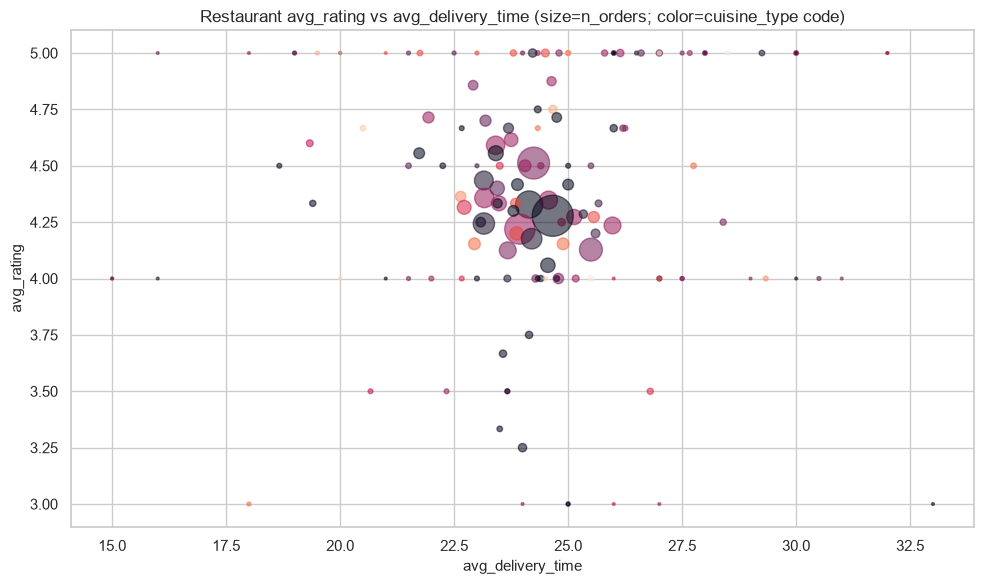

,cuisine_type,cuisine_code
0,American,0
1,Chinese,1
2,French,2
3,Indian,3
4,Italian,4
5,Japanese,5
6,Korean,6
7,Mediterranean,7
8,Mexican,8
9,Middle Eastern,9


In [17]:
rest = restaurants.copy()

# Focus on restaurants with ratings for avg_rating plots
if "has_rated_orders" in rest.columns:
    rest_rated = rest.loc[rest["has_rated_orders"] == True].copy()
else:
    rest_rated = rest.loc[rest["rated_share"] > 0].copy()

# Plot: avg_rating vs avg_delivery_time, size by n_orders, hue by cuisine_type
plt.figure(figsize=(10, 6))
sc = plt.scatter(
    rest_rated["avg_delivery_time"],
    rest_rated["avg_rating"],
    s=(rest_rated["n_orders"].clip(lower=1) * 4),
    c=pd.Categorical(rest_rated["cuisine_type"]).codes,
    alpha=0.55,
)
plt.title("Restaurant avg_rating vs avg_delivery_time (size=n_orders; color=cuisine_type code)")
plt.xlabel("avg_delivery_time")
plt.ylabel("avg_rating")
plt.tight_layout()
plt.show()

# Legend table for cuisine codes
code_map = (
    pd.DataFrame({
        "cuisine_type": pd.Categorical(rest_rated["cuisine_type"]).categories,
        "cuisine_code": range(len(pd.Categorical(rest_rated["cuisine_type"]).categories)),
    })
    .sort_values("cuisine_code")
)
code_map.head(20)

## Extra: Customer-level correlation heatmap (focused)

Descriptive only; helps spot potential confounders/interactions.

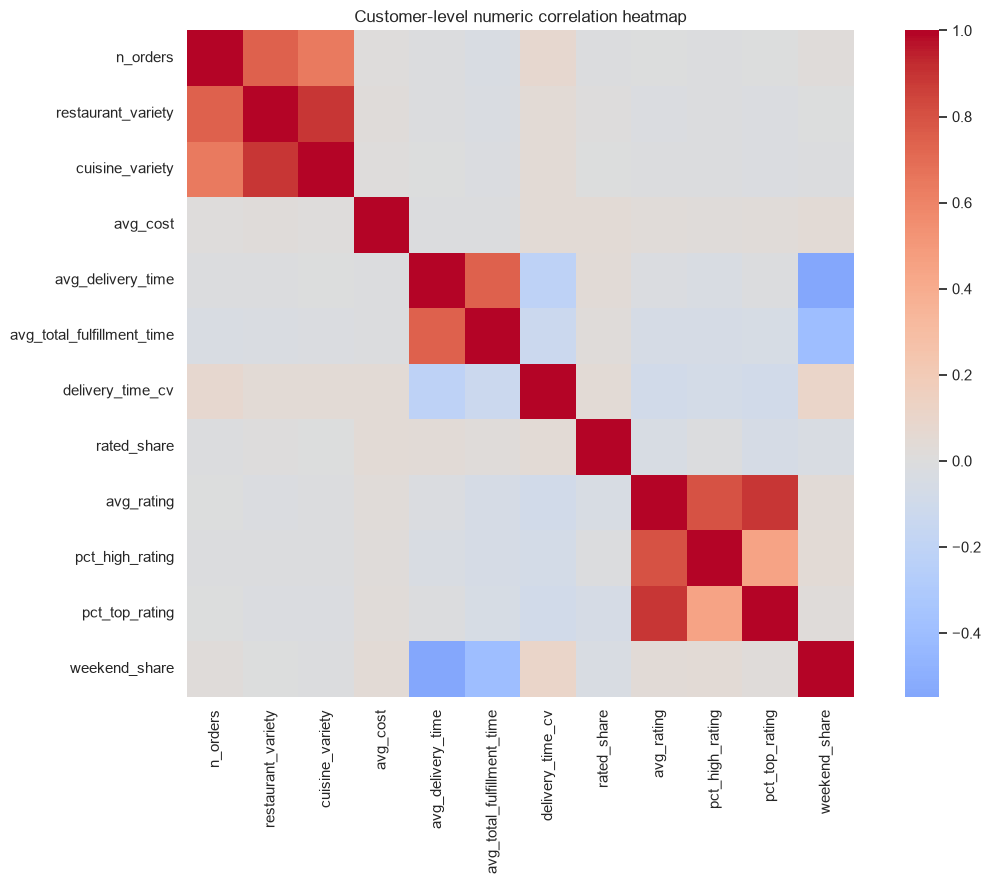

In [18]:
num = cust.select_dtypes(include=["number"]).copy()

keep = [
    c for c in [
        "n_orders",
        "restaurant_variety",
        "cuisine_variety",
        "avg_cost",
        "avg_delivery_time",
        "avg_total_fulfillment_time",
        "delivery_time_cv",
        "rated_share",
        "avg_rating",
        "pct_high_rating",
        "pct_top_rating",
        "weekend_share",
    ]
    if c in num.columns
]

corr = num[keep].corr()

plt.figure(figsize=(12, 9))
sns.heatmap(corr, cmap="coolwarm", center=0, square=True)
plt.title("Customer-level numeric correlation heatmap")
plt.tight_layout()
plt.show()